In [40]:
from Hamiltonian1D import SpinChain1D
import numpy as np
from scipy.sparse import lil_matrix, kron, identity, csr_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from functions import von_neumann_entropy, renyi2_entropy_ED

In [34]:
L = 16
J, g, g_critical = 1.0, 0.5, 1.0
H, H_critical= SpinChain1D(L), SpinChain1D(L)

In [35]:
H.add_zz(J)
H_critical.add_zz(J)

In [36]:
H.add_x_field(g)
H_critical.add_x_field(g_critical)

In [37]:
H = H.build()
H_critical = H_critical.build()


In [21]:
num_eigs = 1  # compute lowest eigenvalue
eigs, vecs = eigsh(H, k=num_eigs, which='SA')
print(f"Ground state energy: {eigs[0]:.6f}")
print(f"Eigenket: {vecs[0]}")

Ground state energy: -11.892045
Eigenket: [1.2148682e-05]


In [38]:
gs_energy_critical, gs_critical = eigsh(H_critical, k=1, which='SA')
gs_energy, gs = eigsh(H, k=1, which='SA')

gs_energy = gs_energy[0]
gs_energy_critical = gs_energy_critical[0]

Physical meaning of eigenvalues λᵢ

They are the Schmidt coefficients squared of 
∣ψ⟩ in the bipartition A⊗B


In Matrix Product States language: the number of significant λᵢ tells us the bond dimension needed to represent the state efficiently.

More non-zero λᵢ → more entanglement → higher bond dimension

In [41]:
subsys_size = list(range(1,L//2 + 1))
S1_critical = [von_neumann_entropy(gs_critical, L, LA) for LA in subsys_size] 
S1 = [von_neumann_entropy(gs, L, LA) for LA in subsys_size]

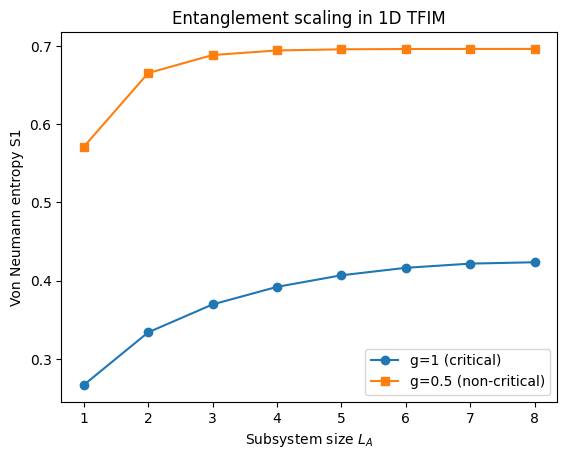

In [42]:
plt.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')
plt.xlabel("Subsystem size $L_A$")
plt.ylabel("Von Neumann entropy S1")

plt.title("Entanglement scaling in 1D TFIM")
plt.legend()
plt.show()

In [43]:
S2_critical = [renyi2_entropy_ED(gs_critical, L, LA) for LA in subsys_size] 
S2 = [renyi2_entropy_ED(gs, L, LA) for LA in subsys_size]

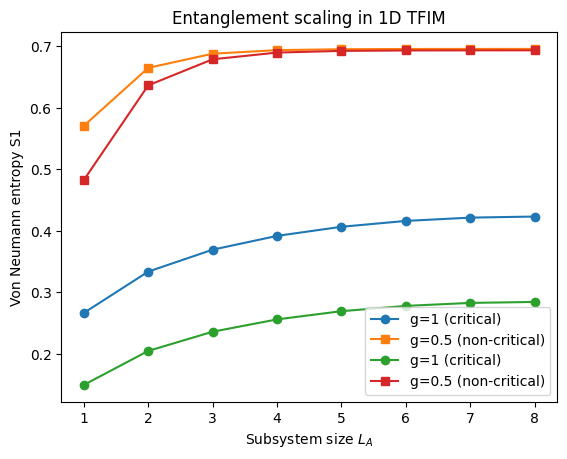

In [44]:
plt.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')

plt.plot(subsys_size, S2_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S2, 's-', label='g=0.5 (non-critical)')

plt.xlabel("Subsystem size $L_A$")
plt.ylabel("Von Neumann entropy S1")

plt.title("Entanglement scaling in 1D TFIM")
plt.legend()
plt.show()